## IDEATLAs ORIGINAL

=== GPU Check ===
Tue Oct 21 02:04:12 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   34C    P0             59W /  400W |    4523MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------

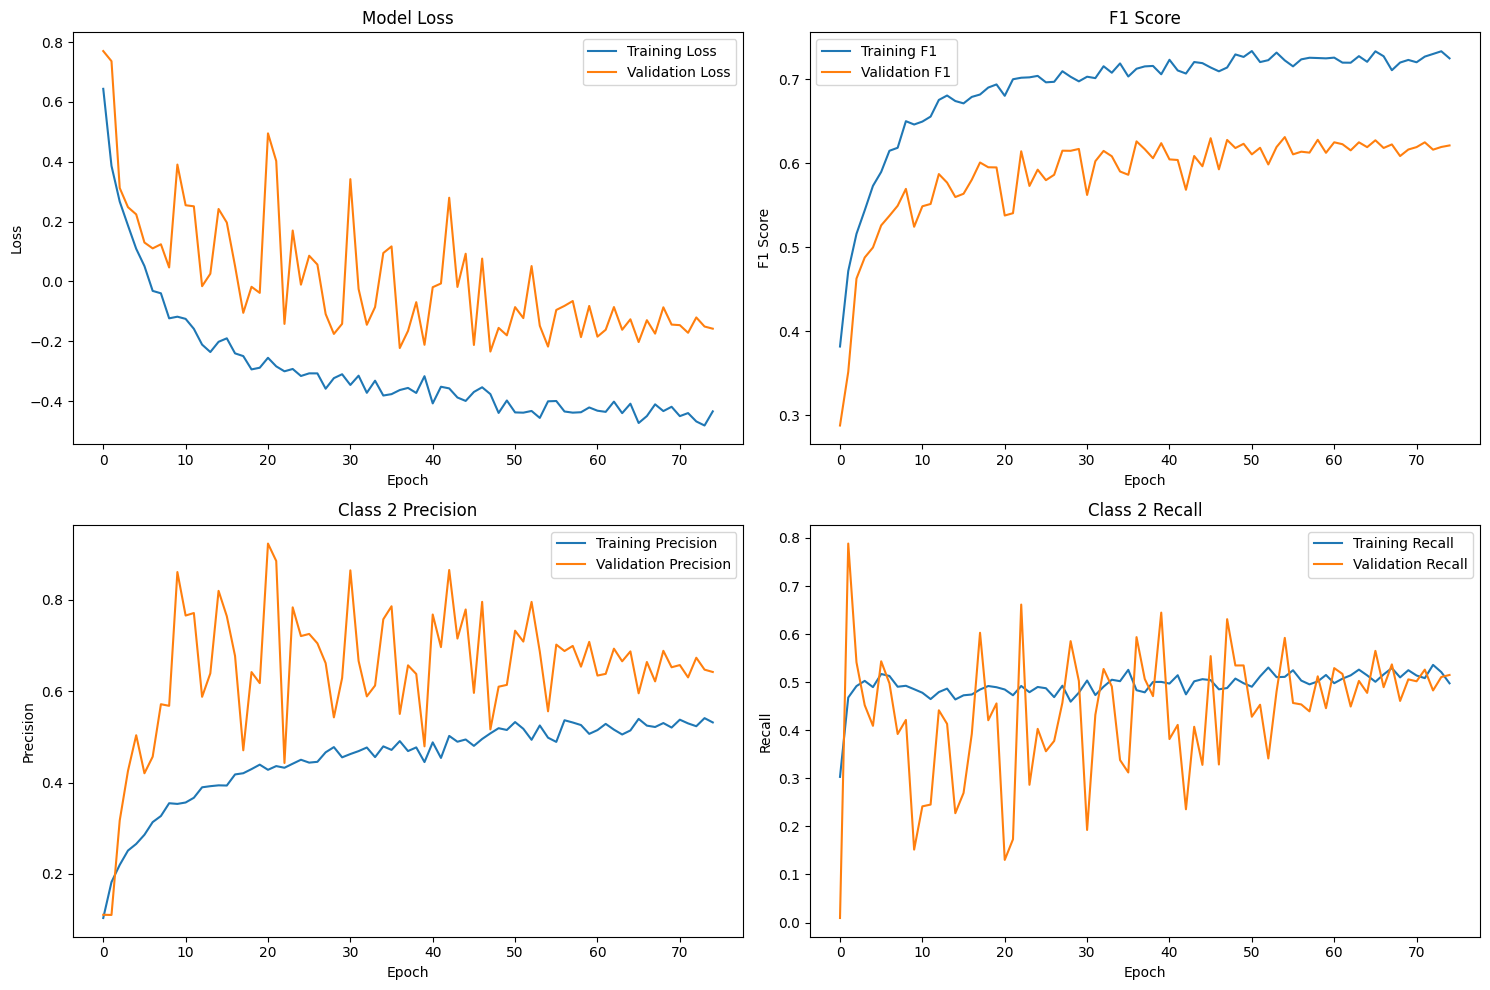


TRAINING SUMMARY
Model: mbcnn
Parameters: 126,371
Final Training Loss: -0.4346
Final Validation Loss: -0.1582
Final Validation F1: 0.6214
Best Validation F1: 0.6313

Model weights saved to: new_morphometrics_multiband/best_model.h5
Training log saved to: log/training_log.csv

✅ IDEatlas pipeline completed successfully!

Next steps:
1. Analyze the results above
2. If needed, adjust focal_alpha, focal_gamma, or dice_focal_ratio
3. Run inference on test set
4. Fine-tune hyperparameters based on Class 2 performance


In [ ]:
# ============================================================================
# IDEATLAS METHODOLOGY ADAPTED FOR GOOGLE COLAB
# Universidad de Twente - Adaptado para segmentación de slums
# ============================================================================

# ================================
# CELL 1: Setup and GPU Check
# ================================
print("=== GPU Check ===")
!nvidia-smi

print("\n=== Installing Required Packages ===")
!pip install segmentation-models -q
!pip install albumentations -q
!pip install rasterio

import os
os.environ["SM_FRAMEWORK"] = "tf.keras"

from tensorflow import keras
import segmentation_models as sm

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import albumentations as A
import glob
import sys
import math

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

# Setup GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(f"GPU setup error: {e}")

# ================================
# CELL 2: Import Custom Modules
# ================================
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.training.data_utils import load_data, calculate_class_weights, patch_class_proportion
from src.training.mbcnn import mbcnn

# ================================
# CELL 3: Configuration (IDEatlas Style)
# ================================
class Config:
    """Configuration class following IDEatlas methodology"""

    # Data paths - ADAPT TO YOUR STRUCTURE
    DATA_PATH = "/content/drive/MyDrive/ML_Inference_Data/new_morphometrics_multiband"
    CHECKPOINT_PATH = "new_morphometrics_multiband"
    LOG_PATH = "log"

    # Model configuration
    PATCH_SIZE = 128
    N_CLASSES = 3
    BATCH_SIZE = 8  # Optimized for Colab
    EPOCHS = 100
    LR = 1e-4  # IDEatlas uses higher LR than your 5e-5

    # Input configuration (IDEatlas style)
    DATASET = ["S2", "DEN"]  # Multiple inputs like IDEatlas
    IN_SHAPE = {
        "S2": (PATCH_SIZE, PATCH_SIZE, 10),
        "DEN": (PATCH_SIZE, PATCH_SIZE, 7)
    }

    # Loss configuration (IDEatlas approach)
    FOCAL_ALPHA = 0.85  # Higher weight for minority class
    FOCAL_GAMMA = 2.5  # More focus on hard examples
    DICE_FOCAL_RATIO = 3.0  # focal_weight / dice_weight (vs IDEatlas 2.0)

    # Training configuration
    DROPOUT_RATE = 0.3
    VALIDATION_SPLIT = 0.2

    def __init__(self):
        # Calculate total input shape for single-input models
        self.input_shapes = {i: self.IN_SHAPE[input] for i, input in enumerate(self.DATASET)}
        h, w, _ = self.IN_SHAPE[self.DATASET[0]]
        c = sum(self.IN_SHAPE[input][2] for input in self.DATASET)
        self.TOTAL_INPUT_SHAPE = [h, w, c]

config = Config()
print("Configuration:")
for attr, value in vars(config).items():
    if not attr.startswith('_'):
        print(f"  {attr}: {value}")

# ================================
# CELL 4: Data Augmentation (IDEatlas Style)
# ================================
def create_augmentation():
    """Create augmentation pipeline following IDEatlas methodology"""
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.Rotate(limit=90, p=0.5, border_mode=0),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
        # More conservative augmentation than your original
        A.ElasticTransform(p=0.1, border_mode=0),  # Reduced probability
    ], additional_targets={'density': 'image'})  # Proper target for density

print("✅ Augmentation pipeline configured!")

# ================================
# CELL 5: Data Loading (Adapted to your structure)
# ================================
def load_all_data(data_dir, config):
    """Load all datasets following your directory structure"""
    print("Loading training data...")

    # Load data using your existing structure
    train_s2 = load_data(os.path.join(data_dir, 'S2', 'train'),
                        config.PATCH_SIZE, config.PATCH_SIZE, 'S2')
    val_s2 = load_data(os.path.join(data_dir, 'S2', 'val'),
                      config.PATCH_SIZE, config.PATCH_SIZE, 'S2')

    train_den = load_data(os.path.join(data_dir, 'DEN', 'train'),
                         config.PATCH_SIZE, config.PATCH_SIZE, 'DEN')
    val_den = load_data(os.path.join(data_dir, 'DEN', 'val'),
                       config.PATCH_SIZE, config.PATCH_SIZE, 'DEN')

    train_labels = load_data(os.path.join(data_dir, 'RF', 'train'),
                            config.PATCH_SIZE, config.PATCH_SIZE, 'RF',
                            n_classes=config.N_CLASSES)
    val_labels = load_data(os.path.join(data_dir, 'RF', 'val'),
                          config.PATCH_SIZE, config.PATCH_SIZE, 'RF',
                          n_classes=config.N_CLASSES)

    print(f"Data shapes:")
    print(f"  Train S2: {train_s2.shape}, Density: {train_den.shape}, Labels: {train_labels.shape}")
    print(f"  Val S2: {val_s2.shape}, Density: {val_den.shape}, Labels: {val_labels.shape}")

    # Class distribution analysis
    patch_class_proportion(np.argmax(train_labels, axis=-1))

    # Calculate class weights (IDEatlas approach)
    class_weights = calculate_class_weights(train_labels)
    print(f"Class weights: {class_weights}")

    return {
        'train_images': [train_s2, train_den],  # IDEatlas multi-input format
        'val_images': [val_s2, val_den],
        'train_labels': train_labels,
        'val_labels': val_labels,
        'class_weights': class_weights
    }

# Clean data function
def clean_data(data_dict):
    """Clean NaN/Inf values"""
    print("Cleaning data...")
    for key, value in data_dict.items():
        if 'images' in key:
            for i, img_array in enumerate(value):
                data_dict[key][i] = np.nan_to_num(img_array, nan=0.0, posinf=1.0, neginf=0.0)
        elif 'labels' in key:
            data_dict[key] = np.nan_to_num(value, nan=0.0, posinf=1.0, neginf=0.0)
    print("✅ Data cleaned!")
    return data_dict

# Load data
print("Loading data from:", config.DATA_PATH)
data = load_all_data(config.DATA_PATH, config)
data = clean_data(data)
print("✅ Data loading completed!")

# ================================
# CELL 5.5: Fix Data Cardinality
# ================================
def fix_data_cardinality(data):
    """Ensure all data arrays have matching sample counts"""
    print("Fixing data cardinality...")

    # Find minimum size across all datasets
    train_sizes = [arr.shape[0] for arr in data['train_images']] + [data['train_labels'].shape[0]]
    val_sizes = [arr.shape[0] for arr in data['val_images']] + [data['val_labels'].shape[0]]

    min_train = min(train_sizes)
    min_val = min(val_sizes)

    print(f"Original train sizes: {train_sizes}")
    print(f"Trimming to minimum: {min_train}")
    print(f"Original val sizes: {val_sizes}")
    print(f"Trimming to minimum: {min_val}")

    # Trim all arrays to minimum size
    data['train_images'] = [arr[:min_train] for arr in data['train_images']]
    data['train_labels'] = data['train_labels'][:min_train]

    data['val_images'] = [arr[:min_val] for arr in data['val_images']]
    data['val_labels'] = data['val_labels'][:min_val]

    # Verify
    print(f"\nFixed train sizes: {[arr.shape[0] for arr in data['train_images']]} + [{data['train_labels'].shape[0]}]")
    print(f"Fixed val sizes: {[arr.shape[0] for arr in data['val_images']]} + [{data['val_labels'].shape[0]}]")

    return data

# Apply the fix
data = fix_data_cardinality(data)
print("✅ Data cardinality fixed!")

# ================================
# CELL 6: Model Creation (IDEatlas + your MBCNN)
# ================================
def create_ideatlas_model(config, class_weights):
    """Create model following IDEatlas methodology with your MBCNN architecture"""

    # Create MBCNN model (your architecture)
    model = mbcnn(
        CL=config.N_CLASSES,
        input_shapes=config.input_shapes,
        dropout_rate=config.DROPOUT_RATE,
        batch_norm=True,
        drop_train=True
    )

    # IDEatlas loss configuration (adapted for your class imbalance)
    dice_loss = sm.losses.DiceLoss(class_weights=class_weights)
    focal_loss = sm.losses.CategoricalFocalLoss(
        alpha=config.FOCAL_ALPHA,  # 0.7 - higher weight for minority class
        gamma=config.FOCAL_GAMMA   # 2.5 - more focus on hard examples
    )

    # IDEatlas combination: dice + (ratio * focal)
    # Increased focal weight to combat your overprediction issue
    combined_loss = dice_loss + (config.DICE_FOCAL_RATIO * focal_loss)

    # Compile with IDEatlas metrics
    model.compile(
        optimizer=Adam(learning_rate=config.LR),
        loss=combined_loss,
        metrics=[
            sm.metrics.FScore(name='f1'),
            tf.keras.metrics.CategoricalAccuracy(name='accuracy'),
            tf.keras.metrics.Precision(class_id=2, name='class2_precision'),
            tf.keras.metrics.Recall(class_id=2, name='class2_recall')
        ]
    )

    return model

# Create model
print("Creating model...")
model = create_ideatlas_model(config, data['class_weights'])
print("✅ Model created!")
print(f"Model parameters: {model.count_params():,}")

# ================================
# CELL 7: Callbacks Setup (IDEatlas Style)
# ================================
def setup_ideatlas_callbacks(config):
    """Setup callbacks following IDEatlas methodology"""

    # Create directories
    os.makedirs(config.CHECKPOINT_PATH, exist_ok=True)
    os.makedirs(config.LOG_PATH, exist_ok=True)

    # Clean old files (IDEatlas approach)
    for file in glob.glob(os.path.join(config.CHECKPOINT_PATH, "*.h5")):
        os.remove(file)
    for file in glob.glob(os.path.join(config.LOG_PATH, "*.csv")):
        os.remove(file)

    # IDEatlas callbacks (adapted)
    callbacks = [
        ModelCheckpoint(
            filepath=os.path.join(config.CHECKPOINT_PATH, "partidos_amba_best_model..weights.h5"),
            monitor="val_f1",  # IDEatlas monitors F1 for best model
            mode="max",
            save_best_only=True,
            save_weights_only=True,
            verbose=1
        ),
        CSVLogger(
            os.path.join(config.LOG_PATH, "training_log.csv")
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=0.5,
            patience=8,
            min_lr=1e-7,
            verbose=1
        ),
        EarlyStopping(
            monitor="val_f1",
            mode="max",
            patience=20,
            restore_best_weights=True,
            verbose=1
        )
    ]

    return callbacks

callbacks = setup_ideatlas_callbacks(config)
print("✅ IDEatlas callbacks configured!")

# ================================
# CELL 8: Training (IDEatlas Style)
# ================================
def print_training_info(data, config):
    """Print training information"""
    print("🚀 Starting IDEatlas-style training...")
    print(f"Training samples: {len(data['train_labels'])}")
    print(f"Validation samples: {len(data['val_labels'])}")
    print(f"Batch size: {config.BATCH_SIZE}")
    print(f"Learning rate: {config.LR}")
    print(f"Loss: Dice + {config.DICE_FOCAL_RATIO}*Focal")

print_training_info(data, config)

# Train the model (IDEatlas approach - direct fit without generators)
history = model.fit(
    data['train_images'],  # List of inputs [S2, DEN]
    data['train_labels'],  # Labels
    batch_size=config.BATCH_SIZE,
    steps_per_epoch=math.ceil(len(data['train_labels']) / config.BATCH_SIZE),
    epochs=config.EPOCHS,
    callbacks=callbacks,
    validation_data=(data['val_images'], data['val_labels']),
    validation_steps=len(data['val_labels']) // config.BATCH_SIZE,
    verbose=1
)

print("✅ IDEatlas training completed!")

# ================================
# CELL 9: Evaluation and Analysis
# ================================
def detailed_evaluation(model, val_images, val_labels, config):
    """Detailed evaluation following your analysis style"""
    print("Generating predictions on validation set...")

    # Generate predictions
    predictions = model.predict(val_images, batch_size=config.BATCH_SIZE)
    pred_classes = np.argmax(predictions, axis=-1)
    true_classes = np.argmax(val_labels, axis=-1)

    # Flatten for analysis
    pred_flat = pred_classes.flatten()
    true_flat = true_classes.flatten()

    print("\n" + "="*50)
    print("DETAILED VALIDATION RESULTS")
    print("="*50)

    # Class distribution
    total_pixels = len(true_flat)
    print(f"Total validation pixels: {total_pixels:,}")
    print("Class distribution:")
    for i in range(config.N_CLASSES):
        count = np.sum(true_flat == i)
        percentage = 100 * count / total_pixels
        print(f"  Class {i}: {count:,} pixels ({percentage:.1f}%)")

    # Confusion matrix
    conf_matrix = confusion_matrix(true_flat, pred_flat)
    print(f"\nConfusion Matrix (Raw Counts):")
    print("Rows = True, Columns = Predicted")
    print(conf_matrix)

    # Confusion matrix percentages
    conf_matrix_pct = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100
    print(f"\nConfusion Matrix (Percentages):")
    print("Rows = True, Columns = Predicted")
    for i in range(config.N_CLASSES):
        row_str = f"Class {i}: "
        for j in range(config.N_CLASSES):
            row_str += f"{conf_matrix_pct[i,j]:5.1f}% "
        print(row_str)

    # Classification report
    print(f"\nClassification Report:")
    class_names = [f'Class_{i}' for i in range(config.N_CLASSES)]
    report = classification_report(true_flat, pred_flat, target_names=class_names)
    print(report)

    # Class 2 specific analysis (your slums analysis)
    print("\n" + "="*30)
    print("CLASS 2 (SLUMS) ANALYSIS")
    print("="*30)

    true_class2 = np.sum(true_flat == 2)
    pred_class2 = np.sum(pred_flat == 2)
    correct_class2 = np.sum((true_flat == 2) & (pred_flat == 2))
    false_positives = pred_class2 - correct_class2
    false_negatives = true_class2 - correct_class2

    print(f"True Class 2 pixels: {true_class2:,}")
    print(f"Predicted Class 2 pixels: {pred_class2:,}")
    print(f"Correctly identified: {correct_class2:,}")
    print(f"False positives: {false_positives:,}")
    print(f"False negatives: {false_negatives:,}")

    # Precision, Recall, F1 for Class 2
    precision_2 = correct_class2 / pred_class2 if pred_class2 > 0 else 0
    recall_2 = correct_class2 / true_class2 if true_class2 > 0 else 0
    f1_2 = 2 * (precision_2 * recall_2) / (precision_2 + recall_2) if (precision_2 + recall_2) > 0 else 0

    print(f"\nClass 2 Metrics:")
    print(f"Precision: {precision_2:.3f}")
    print(f"Recall: {recall_2:.3f}")
    print(f"F1-Score: {f1_2:.3f}")

    # False positives analysis
    print(f"\nFalse Positives Analysis (what's being misclassified as slums):")
    for i in range(config.N_CLASSES):
        if i != 2:
            misclassified = np.sum((true_flat == i) & (pred_flat == 2))
            total_class_i = np.sum(true_flat == i)
            percentage = 100 * misclassified / total_class_i if total_class_i > 0 else 0
            print(f"  {misclassified:,} Class {i} pixels ({percentage:.1f}% of all Class {i})")

# Run detailed evaluation
detailed_evaluation(model, data['val_images'], data['val_labels'], config)

# ================================
# CELL 10: Plot Training History
# ================================
def plot_training_history(history):
    """Plot training history"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Loss
    axes[0,0].plot(history.history['loss'], label='Training Loss')
    axes[0,0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0,0].set_title('Model Loss')
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].set_ylabel('Loss')
    axes[0,0].legend()

    # F1 Score
    axes[0,1].plot(history.history['f1'], label='Training F1')
    axes[0,1].plot(history.history['val_f1'], label='Validation F1')
    axes[0,1].set_title('F1 Score')
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].set_ylabel('F1 Score')
    axes[0,1].legend()

    # Class 2 Precision
    axes[1,0].plot(history.history['class2_precision'], label='Training Precision')
    axes[1,0].plot(history.history['val_class2_precision'], label='Validation Precision')
    axes[1,0].set_title('Class 2 Precision')
    axes[1,0].set_xlabel('Epoch')
    axes[1,0].set_ylabel('Precision')
    axes[1,0].legend()

    # Class 2 Recall
    axes[1,1].plot(history.history['class2_recall'], label='Training Recall')
    axes[1,1].plot(history.history['val_class2_recall'], label='Validation Recall')
    axes[1,1].set_title('Class 2 Recall')
    axes[1,1].set_xlabel('Epoch')
    axes[1,1].set_ylabel('Recall')
    axes[1,1].legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history)

# ================================
# CELL 12: Save Results and Model Info
# ================================
print("\n" + "="*50)
print("TRAINING SUMMARY")
print("="*50)
print(f"Model: {model.name}")
print(f"Parameters: {model.count_params():,}")
print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")
print(f"Final Validation F1: {history.history['val_f1'][-1]:.4f}")
print(f"Best Validation F1: {max(history.history['val_f1']):.4f}")

print(f"\nModel weights saved to: {config.CHECKPOINT_PATH}/best_model.h5")
print(f"Training log saved to: {config.LOG_PATH}/training_log.csv")

print("\n✅ IDEatlas pipeline completed successfully!")
print("\nNext steps:")
print("1. Analyze the results above")
print("2. If needed, adjust focal_alpha, focal_gamma, or dice_focal_ratio")
print("3. Run inference on test set")
print("4. Fine-tune hyperparameters based on Class 2 performance")

# Fine-Tuning


In [ ]:
# ============================================================================
# DOMAIN ADAPTATION FINE-TUNING FOR PARTIDOS AMBA
# Conservative approach to adapt working model to new area
# ============================================================================

# ================================
# CELL 1: Setup and GPU Check
# ================================
print("=== GPU Check ===")
!nvidia-smi

print("\n=== Installing Required Packages ===")
!pip install segmentation-models -q
!pip install albumentations -q
!pip install rasterio -q

import os
os.environ["SM_FRAMEWORK"] = "tf.keras"

from tensorflow import keras
import segmentation_models as sm

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import albumentations as A
import glob
import sys
import math

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

# Setup GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(f"GPU setup error: {e}")

# ================================
# CELL 2: Import Custom Modules
# ================================
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.training.data_utils import load_data, calculate_class_weights, patch_class_proportion
from src.training.mbcnn import mbcnn

# ================================
# CELL 3: Domain Adaptation Configuration
# ================================
class DomainAdaptConfig:
    """Conservative configuration for domain adaptation to Partidos AMBA"""

    # Data paths - UPDATE IF DIFFERENT
    DATA_PATH = "/content/drive/MyDrive/ML_Inference_Data/partidos_amba_2020"
    PRETRAINED_MODEL_PATH = "/content/drive/MyDrive/Fine-Tuning-Workflow/checkpoint/best_model..weights.h5"

    # Output paths
    CHECKPOINT_PATH = "checkpoint_partidos_amba_adapted"
    LOG_PATH = "log_adaptation"

    # Model configuration (MUST MATCH ORIGINAL MODEL)
    PATCH_SIZE = 128
    N_CLASSES = 3
    BATCH_SIZE = 8
    DROPOUT_RATE = 0.3

    # Input configuration (MUST MATCH ORIGINAL MODEL)
    DATASET = ["S2", "DEN"]
    IN_SHAPE = {
        "S2": (PATCH_SIZE, PATCH_SIZE, 10),
        "DEN": (PATCH_SIZE, PATCH_SIZE, 7)
    }

    # CONSERVATIVE DOMAIN ADAPTATION SETTINGS
    FINETUNE_LR = 2e-4            # Ultra-low learning rate (was 1e-4 in original)
    FINETUNE_EPOCHS = 60            # Short adaptation period

    # MODERATE Class 2 boosting (not aggressive)
    CLASS2_WEIGHT_MULTIPLIER = 50.0  # Moderate boost (not 10x)
    FOCAL_ALPHA = 0.99              # Moderate minority class focus
    FOCAL_GAMMA = 4.5               # Standard hard example focus
    DICE_FOCAL_RATIO = 20        # Balanced dice/focal ratio

    # Early stopping patience (generous to allow adaptation)
    EARLY_STOPPING_PATIENCE = 25
    LR_REDUCE_PATIENCE = 12

    def __init__(self):
        # Calculate total input shape
        self.input_shapes = {i: self.IN_SHAPE[input] for i, input in enumerate(self.DATASET)}
        h, w, _ = self.IN_SHAPE[self.DATASET[0]]
        c = sum(self.IN_SHAPE[input][2] for input in self.DATASET)
        self.TOTAL_INPUT_SHAPE = [h, w, c]

config = DomainAdaptConfig()

print("="*70)
print("DOMAIN ADAPTATION CONFIGURATION")
print("="*70)
print(f"Pretrained model: {os.path.basename(config.PRETRAINED_MODEL_PATH)}")
print(f"Target area: Partidos AMBA 2020")
print(f"\nFine-tuning Strategy: CONSERVATIVE DOMAIN ADAPTATION")
print(f"  Learning rate: {config.FINETUNE_LR:.2e} (ultra-low)")
print(f"  Class 2 weight multiplier: {config.CLASS2_WEIGHT_MULTIPLIER}x (moderate)")
print(f"  Focal alpha: {config.FOCAL_ALPHA}")
print(f"  Focal gamma: {config.FOCAL_GAMMA}")
print(f"  Dice/Focal ratio: {config.DICE_FOCAL_RATIO}")
print(f"  Max epochs: {config.FINETUNE_EPOCHS}")
print("="*70)

# ================================
# CELL 4: Load Data
# ================================
def load_all_data(data_dir, config):
    """Load Partidos AMBA training and validation data"""
    print("\n" + "="*70)
    print("LOADING PARTIDOS AMBA DATA")
    print("="*70)

    # Load data
    train_s2 = load_data(os.path.join(data_dir, 'S2', 'train'),
                        config.PATCH_SIZE, config.PATCH_SIZE, 'S2')
    val_s2 = load_data(os.path.join(data_dir, 'S2', 'val'),
                      config.PATCH_SIZE, config.PATCH_SIZE, 'S2')

    train_den = load_data(os.path.join(data_dir, 'DEN', 'train'),
                         config.PATCH_SIZE, config.PATCH_SIZE, 'DEN')
    val_den = load_data(os.path.join(data_dir, 'DEN', 'val'),
                       config.PATCH_SIZE, config.PATCH_SIZE, 'DEN')

    train_labels = load_data(os.path.join(data_dir, 'RF', 'train'),
                            config.PATCH_SIZE, config.PATCH_SIZE, 'RF',
                            n_classes=config.N_CLASSES)
    val_labels = load_data(os.path.join(data_dir, 'RF', 'val'),
                          config.PATCH_SIZE, config.PATCH_SIZE, 'RF',
                          n_classes=config.N_CLASSES)

    print(f"\nData shapes:")
    print(f"  Train S2: {train_s2.shape}, Density: {train_den.shape}, Labels: {train_labels.shape}")
    print(f"  Val S2: {val_s2.shape}, Density: {val_den.shape}, Labels: {val_labels.shape}")

    # Class distribution analysis
    print("\nClass distribution in training data:")
    patch_class_proportion(np.argmax(train_labels, axis=-1))

    # Calculate class weights
    class_weights = calculate_class_weights(train_labels)
    print(f"\nCalculated class weights: {class_weights}")

    return {
        'train_images': [train_s2, train_den],
        'val_images': [val_s2, val_den],
        'train_labels': train_labels,
        'val_labels': val_labels,
        'class_weights': class_weights
    }

def fix_data_cardinality(data):
    """Ensure all data arrays have matching sample counts"""
    print("\nFixing data cardinality...")

    train_sizes = [arr.shape[0] for arr in data['train_images']] + [data['train_labels'].shape[0]]
    val_sizes = [arr.shape[0] for arr in data['val_images']] + [data['val_labels'].shape[0]]

    min_train = min(train_sizes)
    min_val = min(val_sizes)

    print(f"Original train sizes: {train_sizes} → Trimming to: {min_train}")
    print(f"Original val sizes: {val_sizes} → Trimming to: {min_val}")

    data['train_images'] = [arr[:min_train] for arr in data['train_images']]
    data['train_labels'] = data['train_labels'][:min_train]

    data['val_images'] = [arr[:min_val] for arr in data['val_images']]
    data['val_labels'] = data['val_labels'][:min_val]

    print(f"✅ Fixed train sizes: {[arr.shape[0] for arr in data['train_images']]} + [{data['train_labels'].shape[0]}]")
    print(f"✅ Fixed val sizes: {[arr.shape[0] for arr in data['val_images']]} + [{data['val_labels'].shape[0]}]")

    return data

def clean_data(data_dict):
    """Clean NaN/Inf values"""
    print("\nCleaning data...")
    for key, value in data_dict.items():
        if 'images' in key:
            for i, img_array in enumerate(value):
                data_dict[key][i] = np.nan_to_num(img_array, nan=0.0, posinf=1.0, neginf=0.0)
        elif 'labels' in key:
            data_dict[key] = np.nan_to_num(value, nan=0.0, posinf=1.0, neginf=0.0)
    print("✅ Data cleaned!")
    return data_dict

# Load and prepare data
print(f"Loading data from: {config.DATA_PATH}")
data = load_all_data(config.DATA_PATH, config)
data = fix_data_cardinality(data)
data = clean_data(data)
print("✅ Data loading completed!")

# ================================
# CELL 5: Load Pretrained Model and Setup for Fine-Tuning
# ================================
def load_and_setup_pretrained_model(config, class_weights):
    """Load pretrained model and setup for domain adaptation"""

    print("\n" + "="*70)
    print("LOADING PRETRAINED MODEL")
    print("="*70)

    # Create model with same architecture as original
    print("Reconstructing model architecture...")
    model = mbcnn(
        CL=config.N_CLASSES,
        input_shapes=config.input_shapes,
        dropout_rate=config.DROPOUT_RATE,
        batch_norm=True,
        drop_train=True
    )

    # Build model by doing forward pass
    print("Building model...")
    dummy_inputs = [np.zeros((1,) + config.IN_SHAPE[ds]) for ds in config.DATASET]
    _ = model(dummy_inputs)

    # Load pretrained weights
    print(f"Loading weights from: {os.path.basename(config.PRETRAINED_MODEL_PATH)}")
    if not os.path.exists(config.PRETRAINED_MODEL_PATH):
        raise FileNotFoundError(f"Pretrained model not found: {config.PRETRAINED_MODEL_PATH}")

    model.load_weights(config.PRETRAINED_MODEL_PATH)
    print(f"✅ Pretrained weights loaded successfully!")
    print(f"Model parameters: {model.count_params():,}")

    # Apply MODERATE class weight amplification for domain adaptation
    amplified_weights = class_weights.copy()
    amplified_weights[2] *= config.CLASS2_WEIGHT_MULTIPLIER

    print(f"\n" + "="*70)
    print("LOSS CONFIGURATION FOR DOMAIN ADAPTATION")
    print("="*70)
    print(f"Original class weights: {class_weights}")
    print(f"Amplified class weights: {amplified_weights}")
    print(f"Class 2 amplification: {config.CLASS2_WEIGHT_MULTIPLIER}x (MODERATE)")

    # Conservative loss configuration
    dice_loss = sm.losses.DiceLoss(class_weights=amplified_weights)
    focal_loss = sm.losses.CategoricalFocalLoss(
        alpha=config.FOCAL_ALPHA,
        gamma=config.FOCAL_GAMMA
    )

    combined_loss = dice_loss + (config.DICE_FOCAL_RATIO * focal_loss)

    print(f"\nLoss formula: Dice + ({config.DICE_FOCAL_RATIO} × Focal)")
    print(f"Focal alpha: {config.FOCAL_ALPHA} (moderate minority focus)")
    print(f"Focal gamma: {config.FOCAL_GAMMA} (standard hard example focus)")
    print("="*70)

    # Compile with ULTRA-LOW learning rate for gentle adaptation
    model.compile(
        optimizer=Adam(learning_rate=config.FINETUNE_LR),
        loss=combined_loss,
        metrics=[
            sm.metrics.FScore(name='f1'),
            tf.keras.metrics.CategoricalAccuracy(name='accuracy'),
            tf.keras.metrics.Precision(class_id=2, name='class2_precision'),
            tf.keras.metrics.Recall(class_id=2, name='class2_recall'),
            tf.keras.metrics.Precision(class_id=0, name='class0_precision'),
            tf.keras.metrics.Recall(class_id=0, name='class0_recall'),
            tf.keras.metrics.Precision(class_id=1, name='class1_precision'),
            tf.keras.metrics.Recall(class_id=1, name='class1_recall'),
        ]
    )

    print(f"\n✅ Model compiled for domain adaptation!")
    print(f"Learning rate: {config.FINETUNE_LR:.2e} (ULTRA-LOW for gentle updates)")

    return model

# Load and setup the model
model = load_and_setup_pretrained_model(config, data['class_weights'])

# ================================
# CELL 6: Setup Callbacks for Fine-Tuning
# ================================
def setup_domain_adaptation_callbacks(config):
    """Setup callbacks focused on Class 2 performance while preserving overall quality"""

    print("\n" + "="*70)
    print("CONFIGURING CALLBACKS")
    print("="*70)

    # Create directories
    os.makedirs(config.CHECKPOINT_PATH, exist_ok=True)
    os.makedirs(config.LOG_PATH, exist_ok=True)

    # Clean old files
    for file in glob.glob(os.path.join(config.CHECKPOINT_PATH, "*.h5")):
        os.remove(file)
    for file in glob.glob(os.path.join(config.LOG_PATH, "*.csv")):
        os.remove(file)

    callbacks = [
        # Save best model based on Class 2 recall (primary goal)
        ModelCheckpoint(
            filepath=os.path.join(config.CHECKPOINT_PATH, "partidos_amba_best_recall.weights.h5"),
            monitor="val_class2_recall",
            mode="max",
            save_best_only=True,
            save_weights_only=True,
            verbose=1
        ),

        # Save best model based on Class 2 precision (avoid false positives)
        ModelCheckpoint(
            filepath=os.path.join(config.CHECKPOINT_PATH, "partidos_amba_best_precision.weights.h5"),
            monitor="val_class2_precision",
            mode="max",
            save_best_only=True,
            save_weights_only=True,
            verbose=1
        ),

        # Save best overall F1 (all classes balanced)
        ModelCheckpoint(
            filepath=os.path.join(config.CHECKPOINT_PATH, "partidos_amba_best_overall_f1.weights.h5"),
            monitor="val_f1",
            mode="max",
            save_best_only=True,
            save_weights_only=True,
            verbose=1
        ),

        # CSV Logger
        CSVLogger(
            os.path.join(config.LOG_PATH, "domain_adaptation_log.csv")
        ),

        # Reduce LR when Class 2 recall plateaus
        ReduceLROnPlateau(
            monitor="val_class2_recall",
            mode="max",
            factor=0.5,
            patience=config.LR_REDUCE_PATIENCE,
            min_lr=1e-8,
            verbose=1
        ),

        # Early stopping based on Class 2 recall (generous patience)
        EarlyStopping(
            monitor="val_class2_recall",
            mode="max",
            patience=config.EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            verbose=1
        )
    ]

    print("Checkpoints to be saved:")
    print("  1. partidos_amba_best_recall.weights.h5 (highest Class 2 recall)")
    print("  2. partidos_amba_best_precision.weights.h5 (highest Class 2 precision)")
    print("  3. partidos_amba_best_overall_f1.weights.h5 (best overall performance)")
    print(f"\nEarly stopping patience: {config.EARLY_STOPPING_PATIENCE} epochs")
    print(f"LR reduction patience: {config.LR_REDUCE_PATIENCE} epochs")
    print("="*70)

    return callbacks

callbacks = setup_domain_adaptation_callbacks(config)
print("✅ Callbacks configured!")

# ================================
# CELL 7: Run Domain Adaptation Fine-Tuning
# ================================
print("\n" + "="*70)
print("🚀 STARTING DOMAIN ADAPTATION FINE-TUNING")
print("="*70)
print(f"Strategy: Conservative adaptation to Partidos AMBA")
print(f"Training samples: {len(data['train_labels'])}")
print(f"Validation samples: {len(data['val_labels'])}")
print(f"Batch size: {config.BATCH_SIZE}")
print(f"Learning rate: {config.FINETUNE_LR:.2e} (ultra-low)")
print(f"Max epochs: {config.FINETUNE_EPOCHS}")
print(f"\nGoal: Adapt model to recognize slums in Partidos AMBA")
print(f"      while preserving performance on other classes")
print("="*70 + "\n")

# Train the model
history = model.fit(
    data['train_images'],
    data['train_labels'],
    batch_size=config.BATCH_SIZE,
    steps_per_epoch=math.ceil(len(data['train_labels']) / config.BATCH_SIZE),
    epochs=config.FINETUNE_EPOCHS,
    callbacks=callbacks,
    validation_data=(data['val_images'], data['val_labels']),
    validation_steps=math.ceil(len(data['val_labels']) / config.BATCH_SIZE),
    verbose=1
)

print("\n" + "="*70)
print("✅ DOMAIN ADAPTATION COMPLETED!")
print("="*70)

# ================================
# CELL 8: Detailed Evaluation
# ================================
def detailed_evaluation(model, val_images, val_labels, config, model_name="Model"):
    """Detailed evaluation with Class 2 focus"""
    print("\n" + "="*70)
    print(f"EVALUATING {model_name.upper()}")
    print("="*70)

    # Generate predictions
    predictions = model.predict(val_images, batch_size=config.BATCH_SIZE, verbose=0)
    pred_classes = np.argmax(predictions, axis=-1)
    true_classes = np.argmax(val_labels, axis=-1)

    # Flatten for analysis
    pred_flat = pred_classes.flatten()
    true_flat = true_classes.flatten()

    total_pixels = len(true_flat)
    print(f"Total validation pixels: {total_pixels:,}")

    # Class distribution
    print("\nTrue class distribution:")
    for i in range(config.N_CLASSES):
        count = np.sum(true_flat == i)
        percentage = 100 * count / total_pixels
        print(f"  Class {i}: {count:,} pixels ({percentage:.2f}%)")

    print("\nPredicted class distribution:")
    for i in range(config.N_CLASSES):
        count = np.sum(pred_flat == i)
        percentage = 100 * count / total_pixels
        print(f"  Class {i}: {count:,} pixels ({percentage:.2f}%)")

    # Confusion matrix
    conf_matrix = confusion_matrix(true_flat, pred_flat)
    print(f"\n{'Confusion Matrix (Counts)':^50}")
    print("Rows = True, Columns = Predicted")
    print(conf_matrix)

    # Confusion matrix percentages
    conf_matrix_pct = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100
    print(f"\n{'Confusion Matrix (%)':^50}")
    for i in range(config.N_CLASSES):
        row_str = f"Class {i}: "
        for j in range(config.N_CLASSES):
            row_str += f"{conf_matrix_pct[i,j]:5.1f}% "
        print(row_str)

    # Classification report
    print(f"\n{'Classification Report':^50}")
    class_names = ['Class_0', 'Class_1', 'Class_2_SLUMS']
    report = classification_report(true_flat, pred_flat, target_names=class_names, zero_division=0)
    print(report)

    # Class 2 detailed analysis
    print("\n" + "="*70)
    print("CLASS 2 (SLUMS) DETAILED ANALYSIS")
    print("="*70)

    true_class2 = np.sum(true_flat == 2)
    pred_class2 = np.sum(pred_flat == 2)
    correct_class2 = np.sum((true_flat == 2) & (pred_flat == 2))
    false_positives = pred_class2 - correct_class2
    false_negatives = true_class2 - correct_class2

    print(f"True Class 2 pixels: {true_class2:,}")
    print(f"Predicted Class 2 pixels: {pred_class2:,}")
    print(f"Correctly identified: {correct_class2:,}")
    print(f"False positives: {false_positives:,}")
    print(f"False negatives: {false_negatives:,}")

    precision_2 = correct_class2 / pred_class2 if pred_class2 > 0 else 0
    recall_2 = correct_class2 / true_class2 if true_class2 > 0 else 0
    f1_2 = 2 * (precision_2 * recall_2) / (precision_2 + recall_2) if (precision_2 + recall_2) > 0 else 0

    print(f"\nClass 2 Metrics:")
    print(f"  Precision: {precision_2:.4f} ({100*precision_2:.2f}%)")
    print(f"  Recall: {recall_2:.4f} ({100*recall_2:.2f}%)")
    print(f"  F1-Score: {f1_2:.4f}")

    # False positives breakdown
    if false_positives > 0:
        print(f"\nFalse Positives Analysis:")
        for i in range(config.N_CLASSES):
            if i != 2:
                misclassified = np.sum((true_flat == i) & (pred_flat == 2))
                total_class_i = np.sum(true_flat == i)
                percentage = 100 * misclassified / total_class_i if total_class_i > 0 else 0
                print(f"  {misclassified:,} Class {i} pixels misclassified as slums ({percentage:.2f}% of Class {i})")

    print("="*70)

    return {
        'accuracy': np.mean(pred_flat == true_flat),
        'class2_precision': precision_2,
        'class2_recall': recall_2,
        'class2_f1': f1_2
    }

# Evaluate the final model
final_metrics = detailed_evaluation(model, data['val_images'], data['val_labels'], config,
                                   model_name="Fine-Tuned Model")

# ================================
# CELL 9: Plot Training History
# ================================
def plot_adaptation_history(history, config):
    """Plot training history with focus on Class 2 metrics"""

    fig, axes = plt.subplots(3, 2, figsize=(15, 15))

    # Overall Loss
    axes[0,0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0,0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0,0].set_title('Overall Loss', fontsize=12, fontweight='bold')
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].set_ylabel('Loss')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)

    # Overall F1 Score
    axes[0,1].plot(history.history['f1'], label='Training F1', linewidth=2)
    axes[0,1].plot(history.history['val_f1'], label='Validation F1', linewidth=2)
    axes[0,1].set_title('Overall F1 Score (All Classes)', fontsize=12, fontweight='bold')
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].set_ylabel('F1 Score')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)

    # Class 2 Precision
    axes[1,0].plot(history.history['class2_precision'], label='Training', linewidth=2, color='green')
    axes[1,0].plot(history.history['val_class2_precision'], label='Validation', linewidth=2, color='darkgreen')
    axes[1,0].set_title('Class 2 (Slums) - Precision', fontsize=12, fontweight='bold')
    axes[1,0].set_xlabel('Epoch')
    axes[1,0].set_ylabel('Precision')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)

    # Class 2 Recall
    axes[1,1].plot(history.history['class2_recall'], label='Training', linewidth=2, color='blue')
    axes[1,1].plot(history.history['val_class2_recall'], label='Validation', linewidth=2, color='darkblue')
    axes[1,1].set_title('Class 2 (Slums) - Recall ⭐', fontsize=12, fontweight='bold')
    axes[1,1].set_xlabel('Epoch')
    axes[1,1].set_ylabel('Recall')
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)

    # Accuracy
    axes[2,0].plot(history.history['accuracy'], label='Training', linewidth=2, color='purple')
    axes[2,0].plot(history.history['val_accuracy'], label='Validation', linewidth=2, color='indigo')
    axes[2,0].set_title('Overall Accuracy', fontsize=12, fontweight='bold')
    axes[2,0].set_xlabel('Epoch')
    axes[2,0].set_ylabel('Accuracy')
    axes[2,0].legend()
    axes[2,0].grid(True, alpha=0.3)

    # Class 0 Recall
    axes[2,1].plot(history.history['class0_recall'], label='Training', linewidth=2, color='orange')
    axes[2,1].plot(history.history['val_class0_recall'], label='Validation', linewidth=2, color='darkorange')
    axes[2,1].set_title('Class 0 - Recall', fontsize=12, fontweight='bold')
    axes[2,1].set_xlabel('Epoch')
    axes[2,1].set_ylabel('Recall')
    axes[2,1].legend()
    axes[2,1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(config.LOG_PATH, 'training_history.png'), dpi=150, bbox_inches='tight')
    plt.show()

    print(f"✅ Training history plot saved to: {config.LOG_PATH}/training_history.png")

plot_adaptation_history(history, config)


=== GPU Check ===
Tue Oct 21 02:02:34 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   34C    P0             59W /  400W |    4523MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------

KeyboardInterrupt: 

In [ ]:
# Drive mount removed - not needed in local environment

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
